# Fractional Voting Under Noisy and Adversarial Spatial Reports

This notebook looks at a practical question for the fractional voting system. The original benchmark assumes the system has access to each voter's true position in the spatial map. A real implementation would not have that luxury. It would have to work with reported positions or noisy estimates.

The goal here is to see how the **Fractional Ballot Discrete** system behaves when reported positions are truthful, noisy, biased, or strategically distorted. For reference, the notebook also shows what ordinary plurality voting does on the same electorates.

The comparison uses three sigma values for the fractional system in every case: `0.1`, `0.3`, and `1.0`.

---
## Imports and configuration

In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import fixed_candidates
from electoral_sim.electorate import gaussian_electorate, gaussian_mixture_electorate
from electoral_sim.fractional import FractionalBallotDiscrete
from electoral_sim.fractional_reporting import run_fractional_reporting_simulation
from electoral_sim.metrics import compute_metrics
from electoral_sim.reporting import (
    BiasedNoiseReporting,
    CoalitionMisreporting,
    DirectionalExaggerationReporting,
    GaussianNoiseReporting,
    HonestReporting,
    axis_threshold,
)
from electoral_sim.systems import Plurality
from electoral_sim.utils import plot_electorate

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

SIGMAS = [0.1, 0.3, 1.0]
COMMON_CANDIDATES = fixed_candidates(
    [[0.18, 0.48], [0.38, 0.58], [0.52, 0.50], [0.82, 0.52]],
    ["Left", "Center-Left", "Center", "Right"],
)
SCENARIO_SEEDS = {
    "Consensus center": 10,
    "Polarized two-bloc": 20,
    "Fragmented three-bloc": 30,
}

---
## Preliminary refresher: how the fractional system works

The fractional system starts from a simple spatial idea. Each voter and each candidate has a position in the same ideological map. A voter who is closer to a candidate gives that candidate more support, but does not have to give all of their support to a single option.

For voter $i$ and candidate $k$, let $d_{ik}$ be the Euclidean distance between them in the spatial map. The system converts those distances into fractional support weights using

$$
 w_{ik} = \frac{e^{-d_{ik}/\sigma}}{\sum_j e^{-d_{ij}/\sigma}}.
$$

This means each voter's weights add up to 1 across all candidates.

The parameter $\sigma$ controls how sharply distance matters.

- When $\sigma$ is small, most of a voter's weight goes to the nearest candidate, so the system starts to behave more like plurality.
- When $\sigma$ is larger, weight is spread more smoothly across nearby candidates.

In the discrete fractional system used here, the model averages those voter-level weights across the electorate, uses that average to form a weighted centroid of the candidate positions, and then declares the nearest candidate to that centroid as the winner.

That is why this notebook varies $\sigma = 0.1$, $0.3$, and $1.0$. The smaller value is sharper and less forgiving, while the larger value is smoother and often more robust to noise or manipulation.


---
## Electorates and reporting cases

The notebook uses three electorate types:

- **Consensus center**: most voters cluster near the middle.
- **Polarized two-bloc**: one left bloc and one right bloc.
- **Fragmented three-bloc**: left, center-left, and right blocs all matter.

It also uses five reporting situations:

- **Honest reporting**: the system sees each voter's true position, so the reported map matches the real electorate.
- **Gaussian noise**: every reported position is nudged by random symmetric noise. This is meant to represent ordinary measurement error or imperfect information rather than strategy.
- **Biased estimates**: the left half of the electorate is systematically shifted a bit to the right in the reported data. This is a simple way to model a one-sided polling, data, or inference bias.
- **Directional exaggeration**: the left half of the electorate strategically reports positions farther away from the rightmost candidate. The idea is that voters are not lying arbitrarily; they are stretching their reported distance from a specific rival.
- **Coalition misreporting**: the left half coordinates on a common false location instead of reporting their true spread. This models an organized bloc trying to move the inferred center of opinion by sending a shared strategic signal.

In all three distorted cases, the real electorate stays the same. Only the positions seen by the practical fractional implementation are changed. That lets the notebook ask a clean question: if the system has to work from imperfect or strategic reports, how much does the outcome move away from what real voters would have wanted?

Plurality is included as a truthful reference system. The reporting distortions are applied only to the practical fractional implementation being tested here.


---
## Helper functions

The next cells define the electorates and reporting rules used throughout the notebook.

In [18]:
def make_consensus_center(seed):
    return gaussian_electorate(
        3000,
        mean=[0.48, 0.52],
        cov=[[0.015, 0.0], [0.0, 0.015]],
        rng=np.random.default_rng(seed),
        dim_names=["economic", "social"],
    )


# Two large blocs with modest spread around each pole.
def make_polarized_two_bloc(seed):
    return gaussian_mixture_electorate(
        3000,
        [
            {"weight": 0.48, "mean": [0.24, 0.48], "cov": [[0.018, 0.003], [0.003, 0.015]]},
            {"weight": 0.52, "mean": [0.76, 0.52], "cov": [[0.018, -0.003], [-0.003, 0.015]]},
        ],
        rng=np.random.default_rng(seed),
        dim_names=["economic", "social"],
    )


# Three blocs: a left wing, a center-left wing, and a right wing.
def make_fragmented_three_bloc(seed):
    return gaussian_mixture_electorate(
        3000,
        [
            {"weight": 0.34, "mean": [0.22, 0.46], "cov": [[0.012, 0.001], [0.001, 0.012]]},
            {"weight": 0.30, "mean": [0.42, 0.62], "cov": [[0.012, 0.002], [0.002, 0.012]]},
            {"weight": 0.36, "mean": [0.74, 0.50], "cov": [[0.014, -0.002], [-0.002, 0.012]]},
        ],
        rng=np.random.default_rng(seed),
        dim_names=["economic", "social"],
    )


SCENARIO_FACTORIES = {
    "Consensus center": make_consensus_center,
    "Polarized two-bloc": make_polarized_two_bloc,
    "Fragmented three-bloc": make_fragmented_three_bloc,
}


def make_reporting_cases(seed):
    left_half = axis_threshold(0, 0.45, side="le")
    return [
        (
            "Honest reporting",
            "System sees true positions.",
            HonestReporting(),
        ),
        (
            "Gaussian noise",
            "Everyone is measured with symmetric noise.",
            GaussianNoiseReporting(noise_std=0.05, rng=np.random.default_rng(seed + 1)),
        ),
        (
            "Biased estimates",
            "The left half of the electorate is systematically estimated too far to the right.",
            BiasedNoiseReporting(bias=np.array([0.06, 0.0]), selector=left_half),
        ),
        (
            "Directional exaggeration",
            "The left half strategically reports farther away from Right.",
            DirectionalExaggerationReporting(
                strength=0.14,
                away_from_candidate_idx=3,
                selector=left_half,
            ),
        ),
        (
            "Coalition misreporting",
            "The left half coordinates on a common false report.",
            CoalitionMisreporting(
                target_position=np.array([0.10, 0.58]),
                strength=0.85,
                selector=left_half,
            ),
        ),
    ]


reporting_case_frame = pd.DataFrame(
    [
        {"reporting_case": label, "what_it_means": description}
        for label, description, _ in make_reporting_cases(100)
    ]
)
reporting_case_frame

,reporting_case,what_it_means
0,Honest reporting,System sees true positions.
1,Gaussian noise,Everyone is measured with symmetric noise.
2,Biased estimates,The left half of the electorate is systematica...
3,Directional exaggeration,The left half strategically reports farther aw...
4,Coalition misreporting,The left half coordinates on a common false re...


---
## Electorate snapshots

Before looking at the system results, it helps to see the three electorate shapes directly.

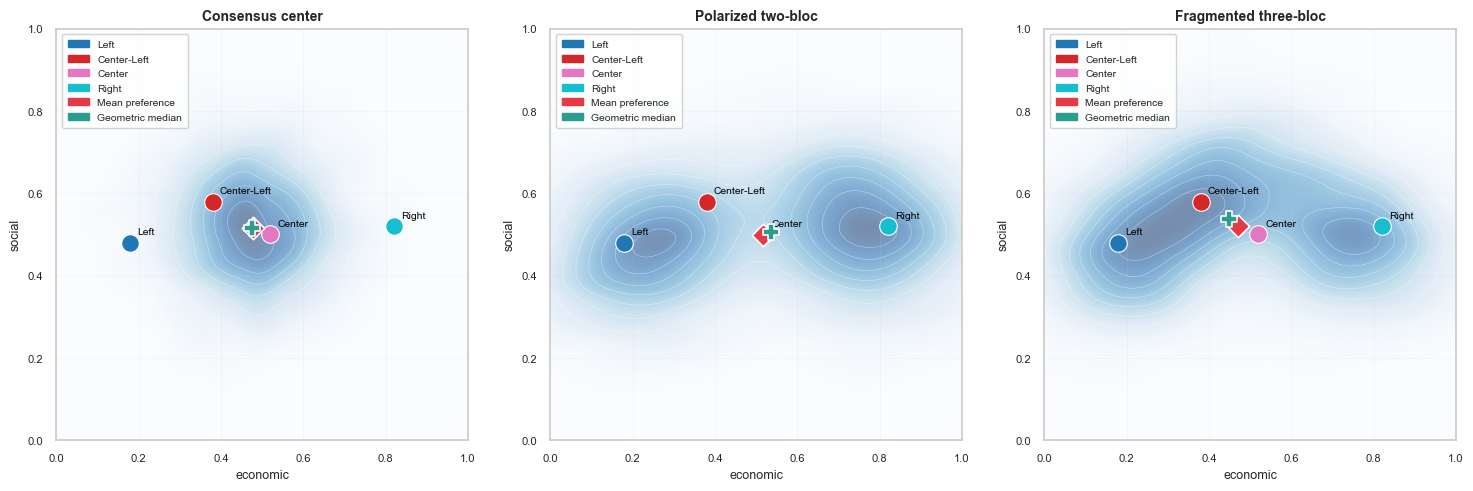

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, (scenario_name, factory) in zip(axes, SCENARIO_FACTORIES.items()):
    electorate = factory(SCENARIO_SEEDS[scenario_name])
    plot_electorate(
        electorate,
        COMMON_CANDIDATES,
        title=scenario_name,
        ax=ax,
    )

plt.tight_layout()

---
## Run the comparison grid

For each electorate and each reporting case, the notebook does two things:

- runs plurality once using truthful rankings,
- runs the fractional discrete system at `σ = 0.1`, `0.3`, and `1.0` under the chosen reporting model.

The fractional outcomes are still evaluated against the true electorate, so the quality metrics tell us whether the implementation remains good for real voters, not just for the reported positions.

In [20]:
def evaluate_scenario(scenario_name, electorate, candidates, reporting_label, reporting_model):
    rows = []

    # Truthful plurality reference.
    ballots = BallotProfile.from_preferences(electorate, candidates)
    plurality_result = Plurality().run(ballots, candidates)
    plurality_metrics = compute_metrics(plurality_result, electorate, candidates)
    plurality_winner = candidates.labels[plurality_result.winner_indices[0]]

    rows.append(
        {
            "scenario": scenario_name,
            "reporting": reporting_label,
            "system": "Plurality",
            "sigma": np.nan,
            "winner": plurality_winner,
            "distance_to_median": plurality_metrics.distance_to_median,
            "mean_voter_distance": plurality_metrics.mean_voter_distance,
            "majority_satisfaction": plurality_metrics.majority_satisfaction,
            "outcome_shift": 0.0,
            "winner_changed": False,
            "plurality_winner": plurality_winner,
            "plurality_distance_to_median": plurality_metrics.distance_to_median,
        }
    )

    # Fractional discrete system under different reporting assumptions.
    for sigma in SIGMAS:
        system = FractionalBallotDiscrete(sigma=sigma)
        run = run_fractional_reporting_simulation(
            electorate,
            candidates,
            system=system,
            reporting_model=reporting_model,
        )
        rows.append(
            {
                "scenario": scenario_name,
                "reporting": reporting_label,
                "system": f"Fractional discrete (σ={sigma})",
                "sigma": sigma,
                "winner": candidates.labels[run.reported_result.winner_indices[0]],
                "distance_to_median": run.reported_metrics.distance_to_median,
                "mean_voter_distance": run.reported_metrics.mean_voter_distance,
                "majority_satisfaction": run.reported_metrics.majority_satisfaction,
                "outcome_shift": run.robustness.outcome_shift,
                "winner_changed": run.robustness.winner_changed,
                "plurality_winner": plurality_winner,
                "plurality_distance_to_median": plurality_metrics.distance_to_median,
            }
        )

    return rows


records = []
for scenario_name, factory in SCENARIO_FACTORIES.items():
    electorate = factory(SCENARIO_SEEDS[scenario_name])
    for reporting_label, _, reporting_model in make_reporting_cases(SCENARIO_SEEDS[scenario_name]):
        records.extend(
            evaluate_scenario(
                scenario_name,
                electorate,
                COMMON_CANDIDATES,
                reporting_label,
                reporting_model,
            )
        )

results = pd.DataFrame(records)
results["d_median_advantage_vs_plurality"] = (
    results["plurality_distance_to_median"] - results["distance_to_median"]
)
results.head(12)

,scenario,reporting,system,sigma,winner,distance_to_median,mean_voter_distance,majority_satisfaction,outcome_shift,winner_changed,plurality_winner,plurality_distance_to_median,d_median_advantage_vs_plurality
0,Consensus center,Honest reporting,Plurality,NaN,Center,0.046,0.159,0.540,0.000,False,Center,0.046,0.000
1,Consensus center,Honest reporting,Fractional discrete (σ=0.1),0.100,Center,0.018,0.154,0.239,0.000,False,Center,0.046,0.029
2,Consensus center,Honest reporting,Fractional discrete (σ=0.3),0.300,Center,0.014,0.154,0.240,0.000,False,Center,0.046,0.032
3,Consensus center,Honest reporting,Fractional discrete (σ=1.0),1.000,Center,0.008,0.153,0.240,0.000,False,Center,0.046,0.039
4,Consensus center,Gaussian noise,Plurality,NaN,Center,0.046,0.159,0.540,0.000,False,Center,0.046,0.000
5,Consensus center,Gaussian noise,Fractional discrete (σ=0.1),0.100,Center,0.016,0.154,0.239,0.002,False,Center,0.046,0.030
6,Consensus center,Gaussian noise,Fractional discrete (σ=0.3),0.300,Center,0.014,0.154,0.241,0.000,False,Center,0.046,0.033
7,Consensus center,Gaussian noise,Fractional discrete (σ=1.0),1.000,Center,0.008,0.153,0.240,0.000,False,Center,0.046,0.039
8,Consensus center,Biased estimates,Plurality,NaN,Center,0.046,0.159,0.540,0.000,False,Center,0.046,0.000
9,Consensus center,Biased estimates,Fractional discrete (σ=0.1),0.100,Center,0.011,0.154,0.241,0.017,False,Center,0.046,0.036


---
## Winners across scenarios and attacks

This table is the quickest high-level summary. It shows the plurality winner and the fractional winner at each sigma for every electorate and reporting case.

In [21]:
winner_table = (
    results.assign(system_label=results["system"])
    .pivot_table(
        index=["scenario", "reporting"],
        columns="system_label",
        values="winner",
        aggfunc="first",
    )
    .reset_index()
)

winner_table

system_label,scenario,reporting,Fractional discrete (σ=0.1),Fractional discrete (σ=0.3),Fractional discrete (σ=1.0),Plurality
0,Consensus center,Biased estimates,Center,Center,Center,Center
1,Consensus center,Coalition misreporting,Center-Left,Center-Left,Center,Center
2,Consensus center,Directional exaggeration,Center-Left,Center,Center,Center
3,Consensus center,Gaussian noise,Center,Center,Center,Center
4,Consensus center,Honest reporting,Center,Center,Center,Center
5,Fragmented three-bloc,Biased estimates,Center,Center,Center,Left
6,Fragmented three-bloc,Coalition misreporting,Center-Left,Center,Center,Left
7,Fragmented three-bloc,Directional exaggeration,Center,Center,Center,Left
8,Fragmented three-bloc,Gaussian noise,Center,Center,Center,Left
9,Fragmented three-bloc,Honest reporting,Center,Center,Center,Left


---
## Distance-to-median compared with plurality

A positive value in the heatmaps below means the fractional system is doing better than plurality on that electorate-reporting combination. A negative value would mean plurality is closer to the geometric median.

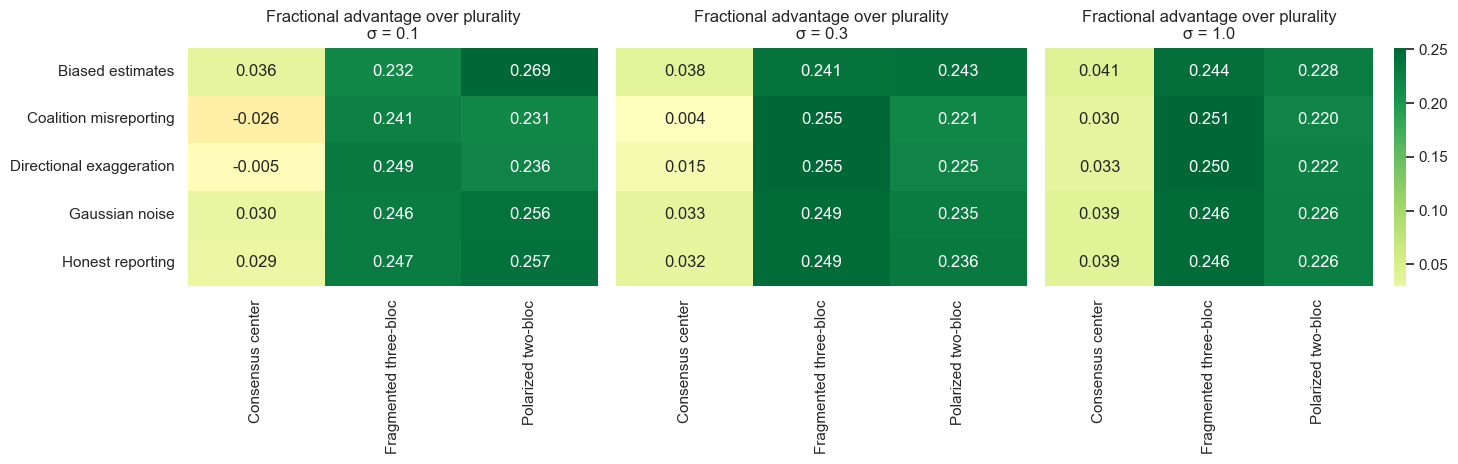

In [22]:
fractional_only = results[results["sigma"].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, sigma in zip(axes, SIGMAS):
    heat = fractional_only[fractional_only["sigma"] == sigma].pivot_table(
        index="reporting",
        columns="scenario",
        values="d_median_advantage_vs_plurality",
        aggfunc="first",
    )
    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0.0,
        ax=ax,
        cbar=ax is axes[-1],
    )
    ax.set_title(f"Fractional advantage over plurality\nσ = {sigma}")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

---
## How much the attacks move the fractional outcome

The next heatmaps show how far the fractional outcome shifts away from its truthful baseline under each reporting case. This is a direct robustness view: lower values mean the implementation is more stable.

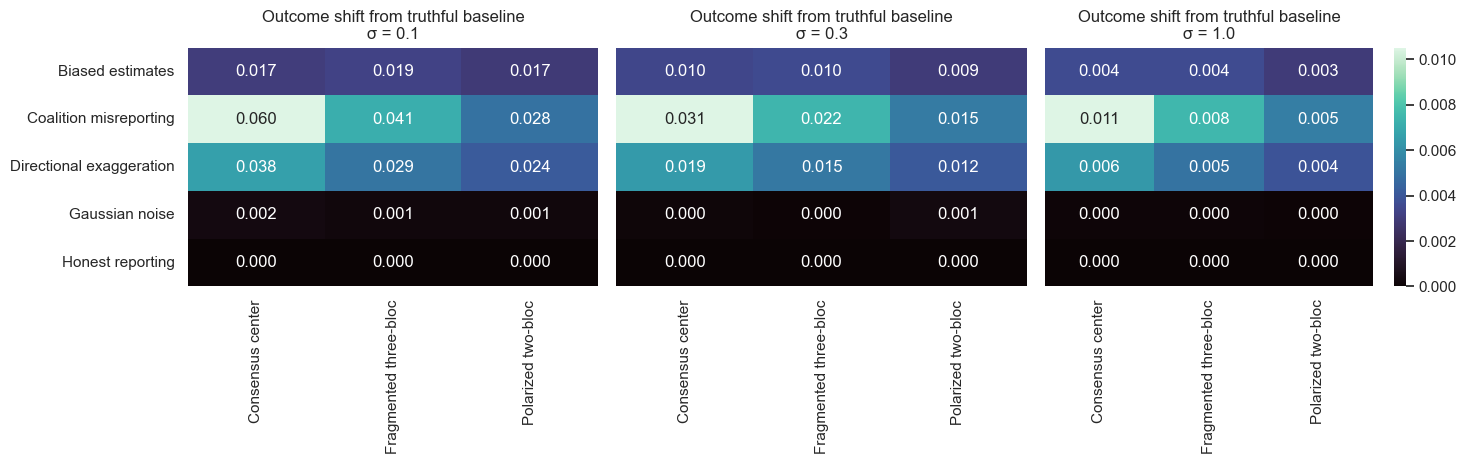

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, sigma in zip(axes, SIGMAS):
    heat = fractional_only[fractional_only["sigma"] == sigma].pivot_table(
        index="reporting",
        columns="scenario",
        values="outcome_shift",
        aggfunc="first",
    )
    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="mako",
        ax=ax,
        cbar=ax is axes[-1],
    )
    ax.set_title(f"Outcome shift from truthful baseline\nσ = {sigma}")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

---
## Compact metric table

This condensed table makes it easier to compare all systems side by side using two simple metrics: distance to the geometric median and mean voter distance.

In [24]:
compact_table = results.copy()
compact_table["sigma_label"] = compact_table["sigma"].map(lambda x: f"σ={x}" if pd.notna(x) else "Plurality")
compact_table = compact_table[
    [
        "scenario",
        "reporting",
        "sigma_label",
        "winner",
        "distance_to_median",
        "mean_voter_distance",
        "outcome_shift",
        "winner_changed",
    ]
].sort_values(["scenario", "reporting", "sigma_label"])

compact_table.reset_index(drop=True)

,scenario,reporting,sigma_label,winner,distance_to_median,mean_voter_distance,outcome_shift,winner_changed
0,Consensus center,Biased estimates,Plurality,Center,0.046,0.159,0.000,False
1,Consensus center,Biased estimates,σ=0.1,Center,0.011,0.154,0.017,False
2,Consensus center,Biased estimates,σ=0.3,Center,0.008,0.153,0.010,False
3,Consensus center,Biased estimates,σ=1.0,Center,0.006,0.153,0.004,False
4,Consensus center,Coalition misreporting,Plurality,Center,0.046,0.159,0.000,False
5,Consensus center,Coalition misreporting,σ=0.1,Center-Left,0.073,0.167,0.060,True
6,Consensus center,Coalition misreporting,σ=0.3,Center-Left,0.043,0.158,0.031,True
7,Consensus center,Coalition misreporting,σ=1.0,Center,0.017,0.154,0.011,False
8,Consensus center,Directional exaggeration,Plurality,Center,0.046,0.159,0.000,False
9,Consensus center,Directional exaggeration,σ=0.1,Center-Left,0.051,0.160,0.038,True


---
## Takeaways

A few patterns stand out in this grid.

- Under **honest reporting**, the fractional discrete system usually improves on plurality in distance-to-median terms, and higher `σ` values often smooth the outcome further.
- **Gaussian noise** is usually the least damaging perturbation in these examples. The system moves a little, but not much.
- **Biased estimates**, **directional exaggeration**, and especially **coalition misreporting** are more dangerous, and they matter most at low `σ`.
- In these examples, `σ = 1.0` is consistently the most stable of the three values, while `σ = 0.1` is the most brittle.
- Even when the fractional winner changes under attack, plurality is not automatically better. In many cells, the attacked fractional outcome is still closer to the electorate's center than plurality.

So despite the somewhat unfair advantage plurality gets (as it is only subject to honest reporting), it is almost always beaten by the fractional discrete system.